In [1]:
import sys
sys.path.insert(0, '../src')

In [2]:
import tensorflow as tf
import numpy as np
import random

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

2026-09-09 22:21:20.215280: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789006880.232548 1552502 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789006880.237859 1552502 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789006880.250028 1552502 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789006880.250044 1552502 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789006880.250046 1552502 computation_placer.cc:177] computation placer alr

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
from data.spleenex import load_spleenex
from data.deepspv  import load_deepspv
from data.roboflow import load_roboflow
from data.base     import combine_datasets, shuffle_arrays, split_train_test

In [5]:
#X_train, y_train, X_test, y_test = load_spleenex()

In [6]:
X_robo, y_robo, _, _ = load_roboflow(split=False)

Roboflow: loaded 208 samples
Roboflow: spleen coverage 7.14%


In [7]:
#X_train, y_train, X_test, y_test = load_deepspv()

In [8]:
#X_train, y_train, X_test, y_test = load_roboflow()

In [9]:
images, masks, case_ids, sources = combine_datasets(
    load_spleenex(split=False),
    load_deepspv(split=False),
)

Spleenex: loaded 450 samples (0 skipped)
Spleenex: spleen coverage 5.64%
DeepSPV: loaded 149 samples (0 skipped)
DeepSPV: spleen coverage 9.31%
Combined: 599 total samples


In [10]:
images, masks, case_ids, sources = shuffle_arrays(images, masks, case_ids, sources, seed=42)

In [11]:
images, masks, case_ids, sources = shuffle_arrays(images, masks, case_ids, sources, seed=42)
X_train, y_train, X_test, y_test = split_train_test(
    images, masks, case_ids, sources,
    test_fraction=0.2,
    log_name="spleenex_deepspv",
    seed=42,
)

Split: 479 train / 120 test (total 599)
Split log saved: /raid/mpsych/SPLEENUS/runs/splits/spleenex_deepspv_seed42.json


In [12]:
from models.unet import UNetSegmentor, bce_dice_loss, dice_metric

I0000 00:00:1789006910.855600 1552502 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:07:00.0, compute capability: 8.0


In [14]:
# train
model = UNetSegmentor("unet")

In [15]:
model.fit(X_train, y_train, epochs=50)

Epoch 1/50


2026-09-09 21:40:39.398371: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1789004443.132962 1506969 cuda_dnn.cc:529] Loaded cuDNN version 90501
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - bin_acc: 0.9318 - dice_metric: 0.0983 - iou: 0.4638 - loss: 1.3647 - precision: 0.0243 - recall: 7.5423e-04

/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:329: UserWarning: Can save best model only with val_dice_metic available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to /raid/mpsych/SPLEENUS/models/best_unet.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 264ms/step - bin_acc: 0.9318 - dice_metric: 0.0983 - iou: 0.4638 - loss: 1.3647 - precision: 0.0243 - recall: 7.5423e-04 - val_bin_acc: 0.9344 - val_dice_metric: 0.1957 - val_iou: 0.4672 - val_loss: 0.9925 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - bin_acc: 0.9338 - dice_metric: 0.2775 - iou: 0.4669 - loss: 0.9133 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: finished saving model to /raid/mpsych/SPLEENUS/models/best_unet.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - bin_acc: 0.9338 - dice_metric: 0.2775 - iou: 0.4669 - loss: 0.9133 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_bin_acc: 0.9344 - val_dice_metric: 0.3291 - val_iou: 0.4672 - val_loss: 0.8442 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━

In [16]:
# eval
metrics = model.evaluate(X_test, y_test)

2026-09-09 21:45:45.195962: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Dice: 0.9229 | IoU: 0.8569


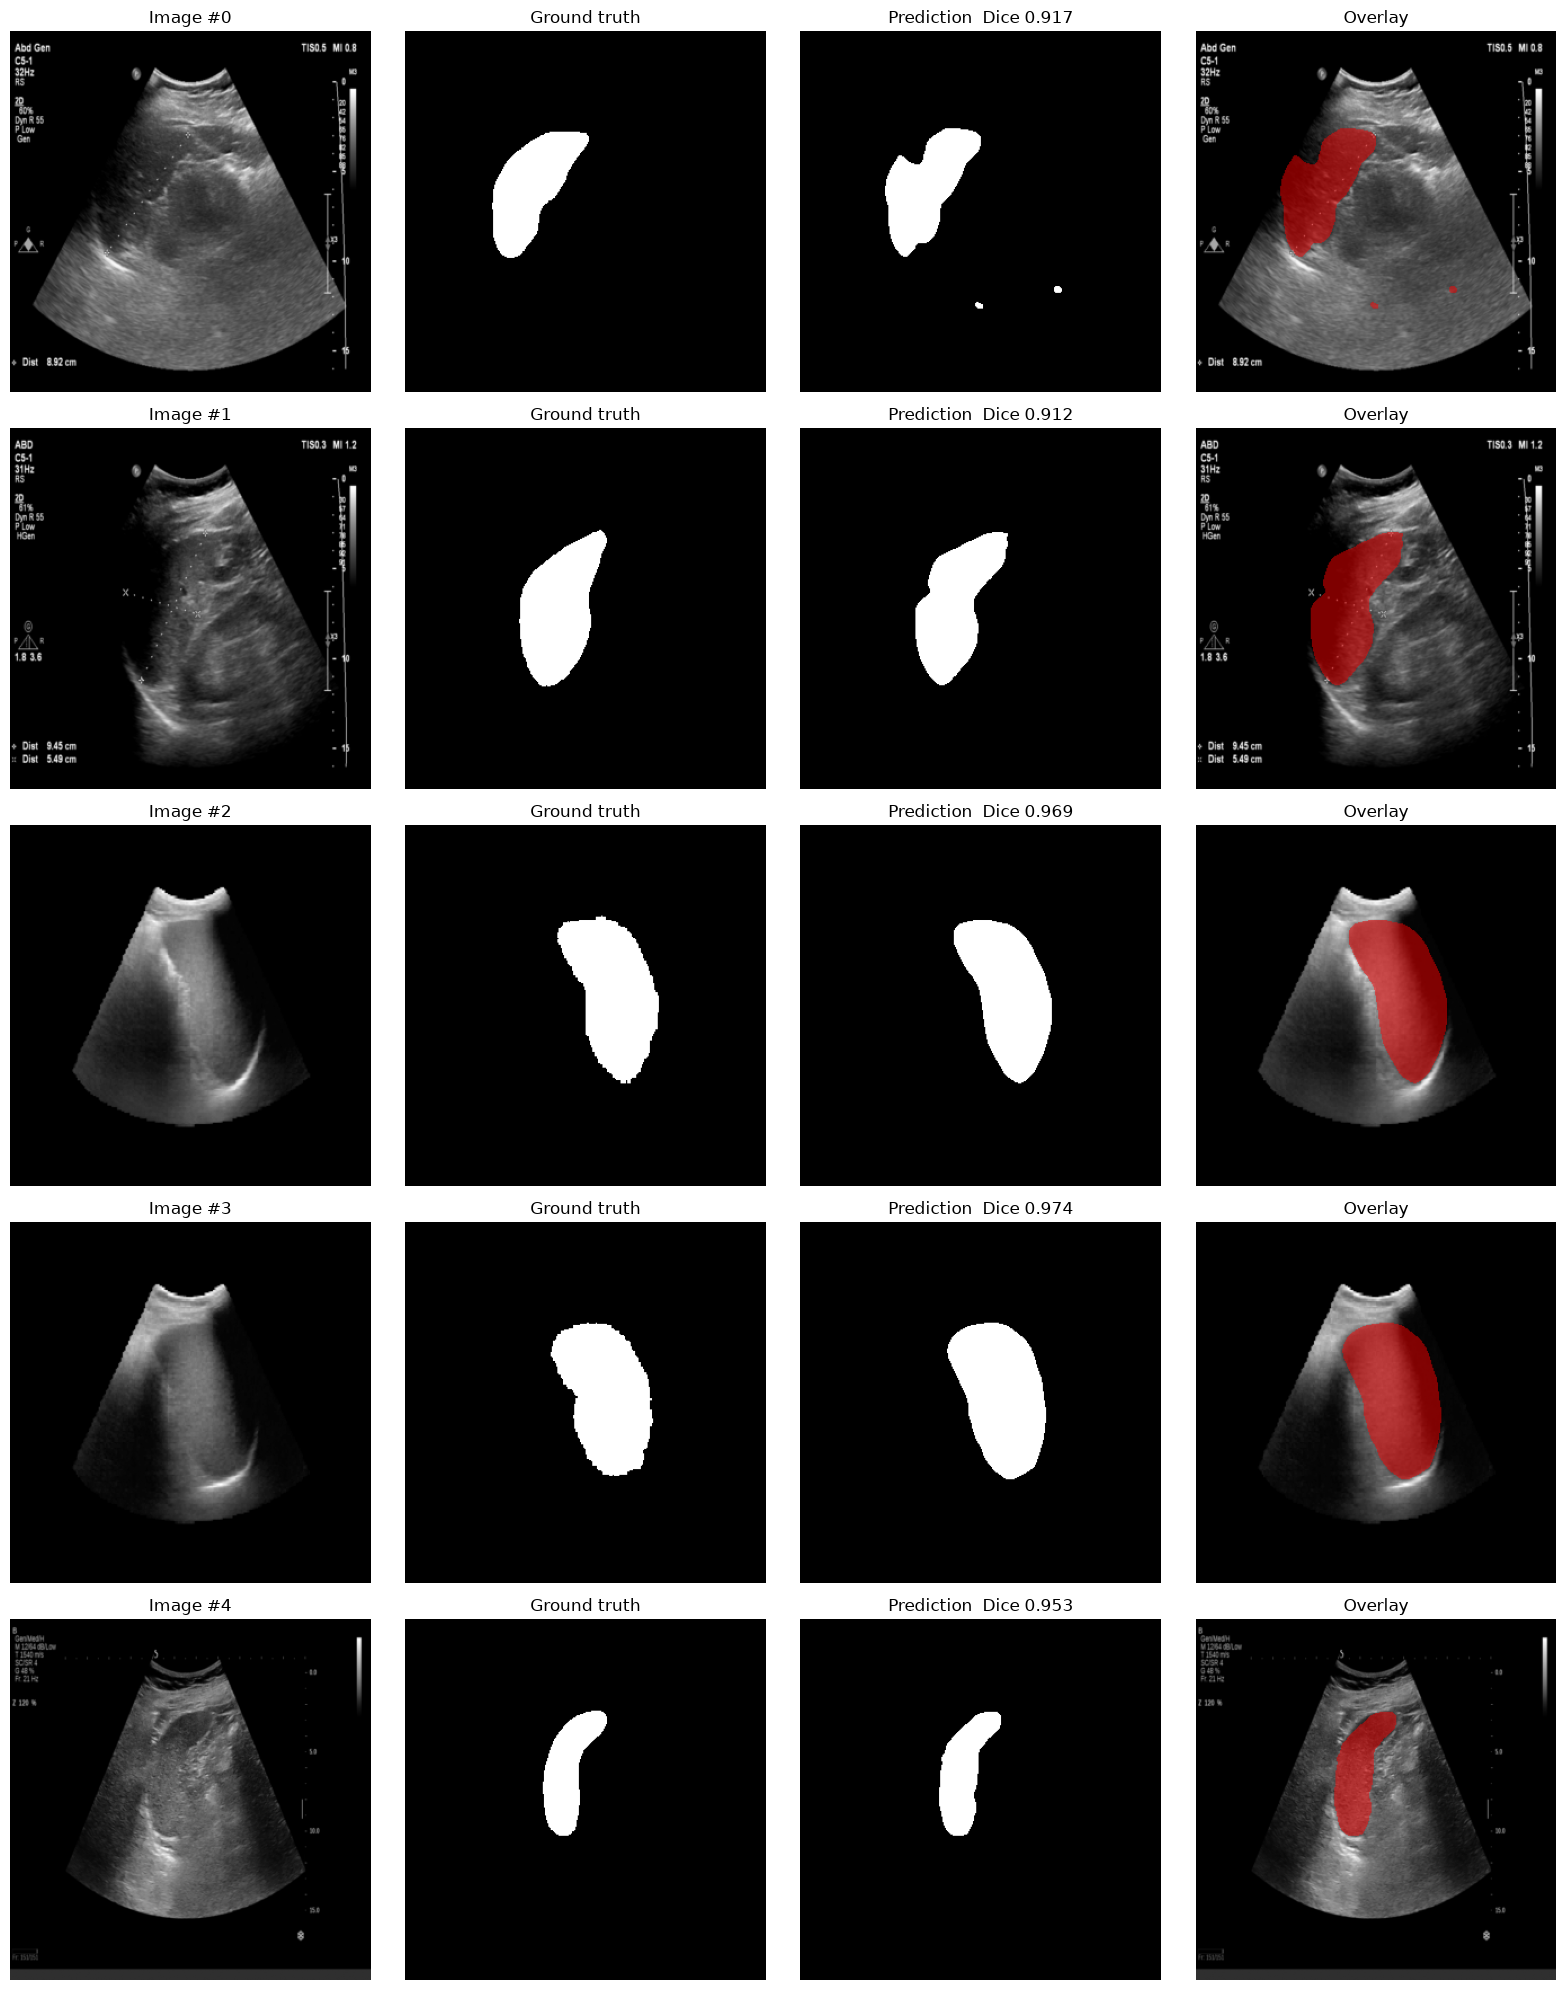

In [17]:
# visualize
model.visualize(X_test, y_test, n=5)

In [18]:
model2 = UNetSegmentor("unet")
model2.load("/raid/mpsych/SPLEENUS/models/best_unet.keras")

Loaded from /raid/mpsych/SPLEENUS/models/best_unet.keras


In [19]:
metrics_after_load = model2.evaluate(X_test, y_test)

Dice: 0.9229 | IoU: 0.8569


In [20]:
metrics_after_load = model2.evaluate(X_robo, y_robo)

Dice: 0.4349 | IoU: 0.2779


In [13]:
model = UNetSegmentor("unet++")

In [14]:
model.fit(X_train, y_train, epochs=50)

Epoch 1/50


2026-09-09 22:21:57.274826: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1789006920.883602 1553058 cuda_dnn.cc:529] Loaded cuDNN version 90501
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - bin_acc: 0.9337 - dice_metric: 0.1047 - iou: 0.4649 - loss: 1.3304 - precision: 5.0492e-04 - recall: 6.8442e-07

/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/keras/src/callbacks/model_checkpoint.py:329: UserWarning: Can save best model only with val_dice_metic available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to /raid/mpsych/SPLEENUS/models/best_unetpp.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 229ms/step - bin_acc: 0.9337 - dice_metric: 0.1047 - iou: 0.4649 - loss: 1.3304 - precision: 5.0492e-04 - recall: 6.8442e-07 - val_bin_acc: 0.9344 - val_dice_metric: 0.2193 - val_iou: 0.4672 - val_loss: 0.9719 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - bin_acc: 0.9338 - dice_metric: 0.2825 - iou: 0.4669 - loss: 0.9057 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: finished saving model to /raid/mpsych/SPLEENUS/models/best_unetpp.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - bin_acc: 0.9338 - dice_metric: 0.2825 - iou: 0.4669 - loss: 0.9057 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_bin_acc: 0.9344 - val_dice_metric: 0.3317 - val_iou: 0.4672 - val_loss: 0.8390 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/50
27/27 ━━━━━━━━━━━

In [15]:
# eval
metrics = model.evaluate(X_test, y_test)

2026-09-09 22:26:35.252930: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Dice: 0.9202 | IoU: 0.8522


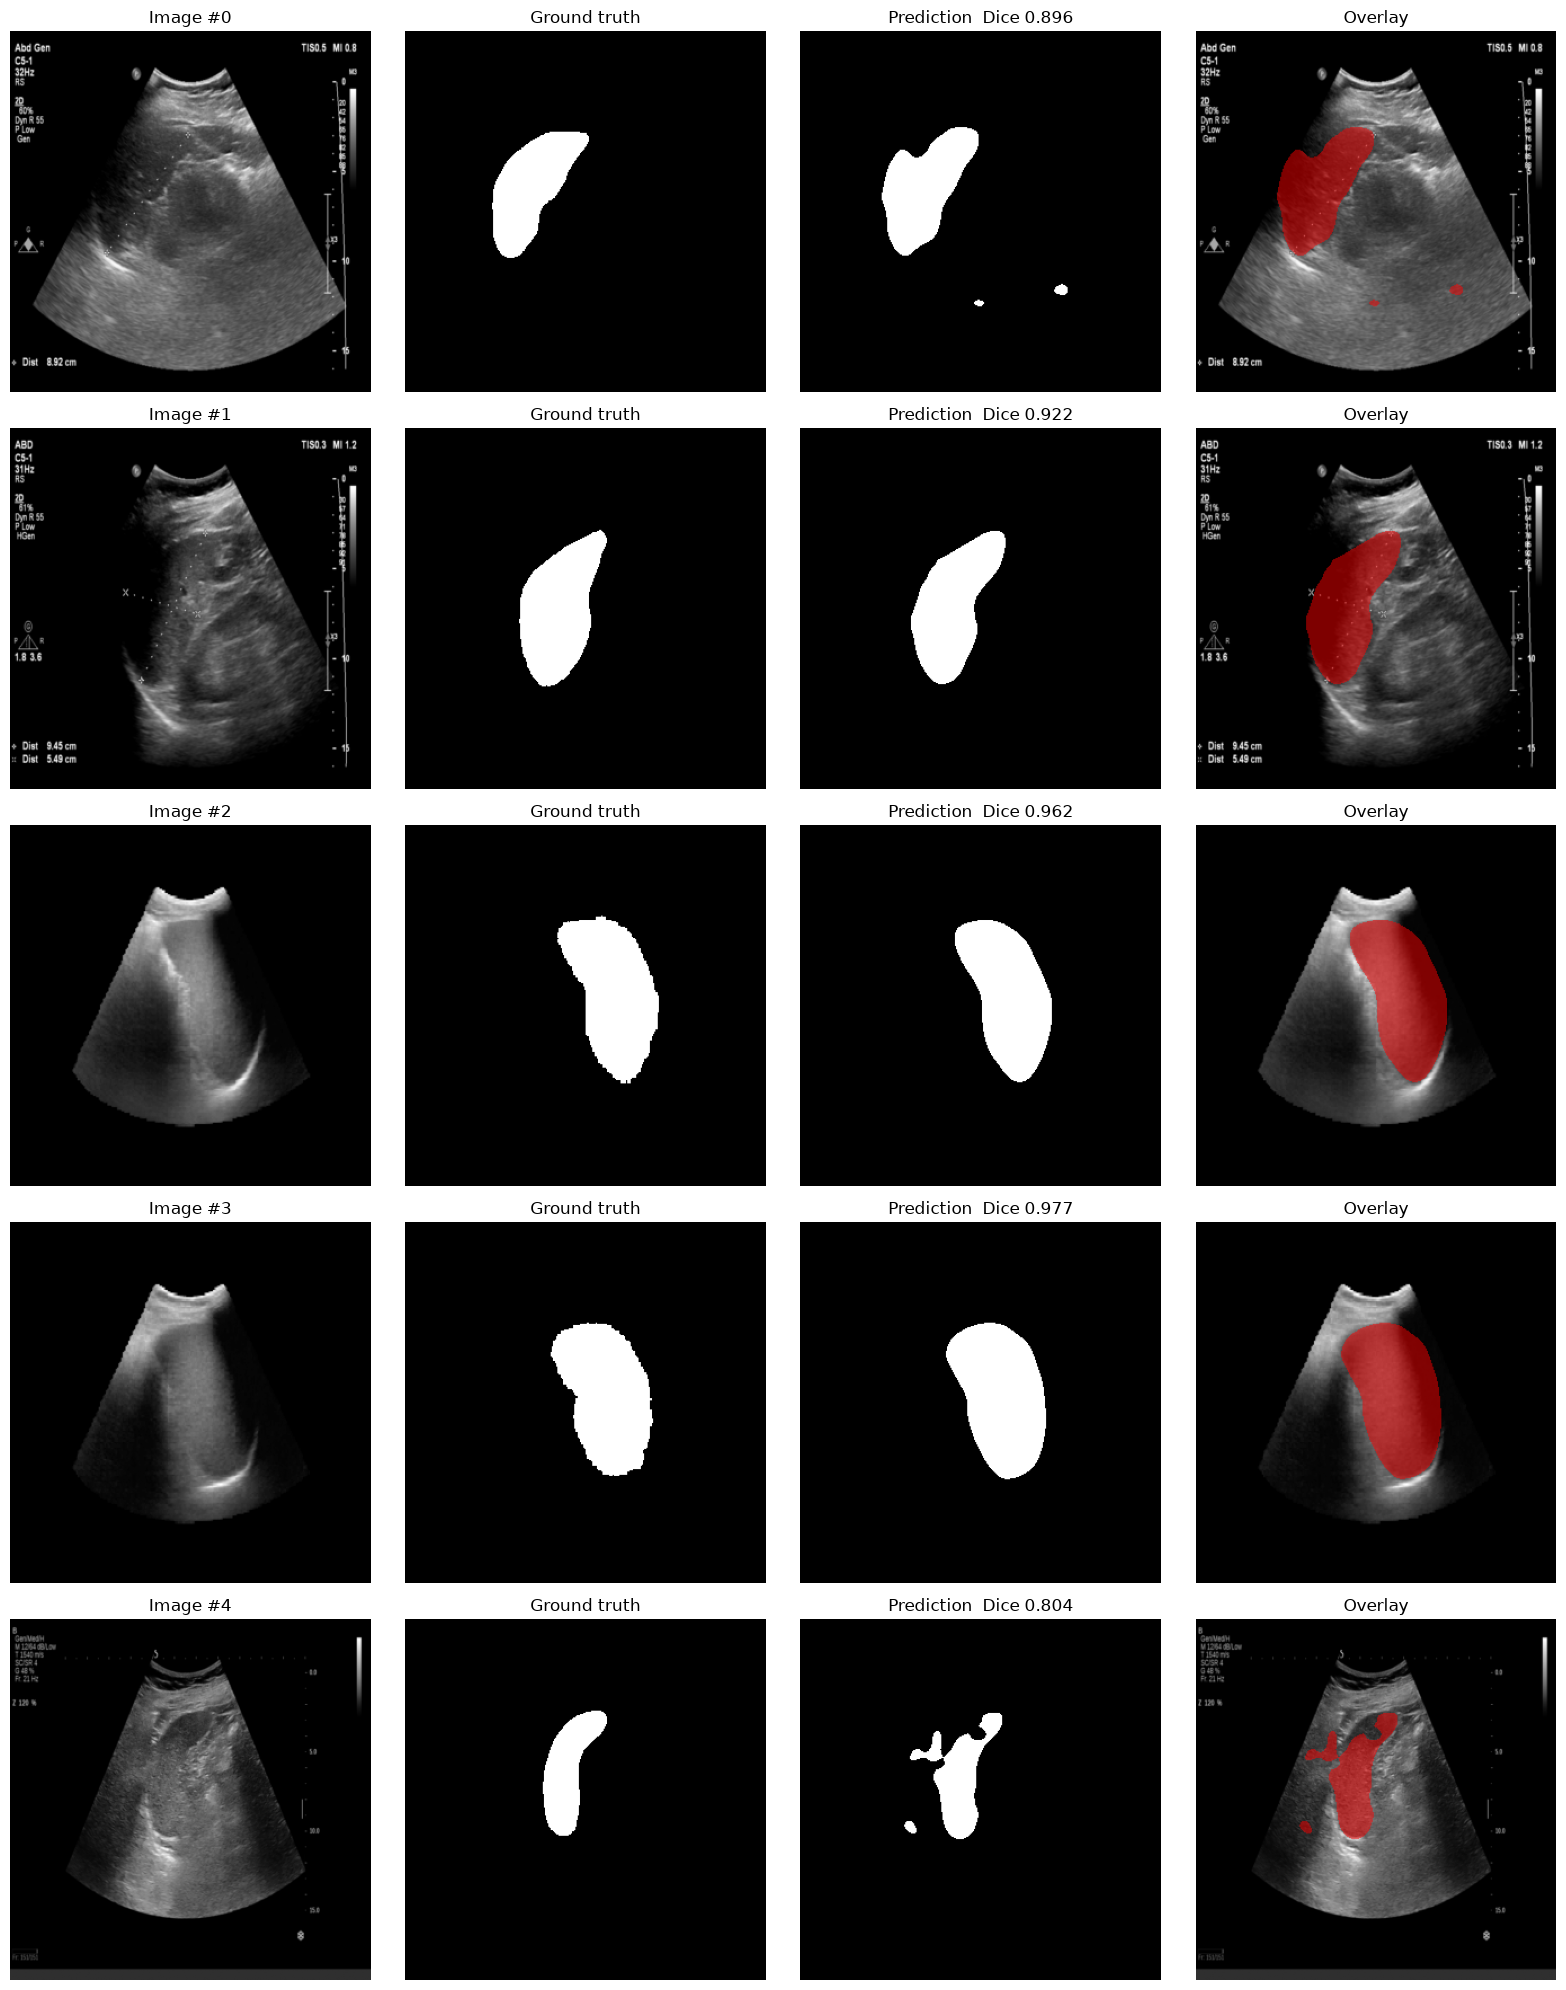

In [16]:
# visualize
model.visualize(X_test, y_test, n=5)

In [17]:
model = UNetSegmentor("unet++")
model.load("/raid/mpsych/SPLEENUS/models/best_unetpp.keras")

Loaded from /raid/mpsych/SPLEENUS/models/best_unetpp.keras


In [18]:
metrics = model.evaluate(X_test, y_test)

Dice: 0.9202 | IoU: 0.8522


In [19]:
metrics = model.evaluate(X_robo, y_robo)

Dice: 0.4485 | IoU: 0.2891


In [28]:
model = UNetSegmentor("unet3++")

Automated hyper-parameter determination is applied with the following details:
----------
	Number of convolution filters after each full-scale skip connection: filter_num_skip = [64, 64, 64]
	Number of channels of full-scale aggregated feature maps: filter_num_aggregate = 256


In [29]:
model.fit(X_train, y_train, epochs=50)

Epoch 1/50


2026-09-09 21:50:30.641741: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - bin_acc: 0.9101 - dice_metric: 0.3610 - iou: 0.6319 - loss: 0.8902 - precision: 0.3906 - recall: 0.6388
Epoch 1: finished saving model to /raid/mpsych/SPLEENUS/models/best_unet3pp.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 540ms/step - bin_acc: 0.9101 - dice_metric: 0.3610 - iou: 0.6319 - loss: 0.8902 - precision: 0.3906 - recall: 0.6388 - val_bin_acc: 0.9344 - val_dice_metric: 0.1157 - val_iou: 0.4672 - val_loss: 1.5283 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - bin_acc: 0.9551 - dice_metric: 0.6028 - iou: 0.7317 - loss: 0.5231 - precision: 0.6478 - recall: 0.7066
Epoch 2: finished saving model to /raid/mpsych/SPLEENUS/models/best_unet3pp.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 502ms/step - bin_acc: 0.9551 - dice_metric: 0.6028 - iou: 0.7317 - loss: 0.5231 - precision: 0.6478 - recall: 0.7066 - val_bin_acc: 0.9344 - val_dice_metric: 0.1157 - val_iou: 0.4672 - v

In [30]:
# eval
metrics = model.evaluate(X_test, y_test)

2026-09-09 22:01:54.830174: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
W0000 00:00:1789005715.108502 1506967 conv_ops_gpu.cc:147] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 32
in_depths: 512
out_depths: 64
in: 320
in: 320
data_format: 1
filter: 3
filter: 3
filter: 512
dilation: 1
dilation: 1
stri

Dice: 0.9174 | IoU: 0.8474


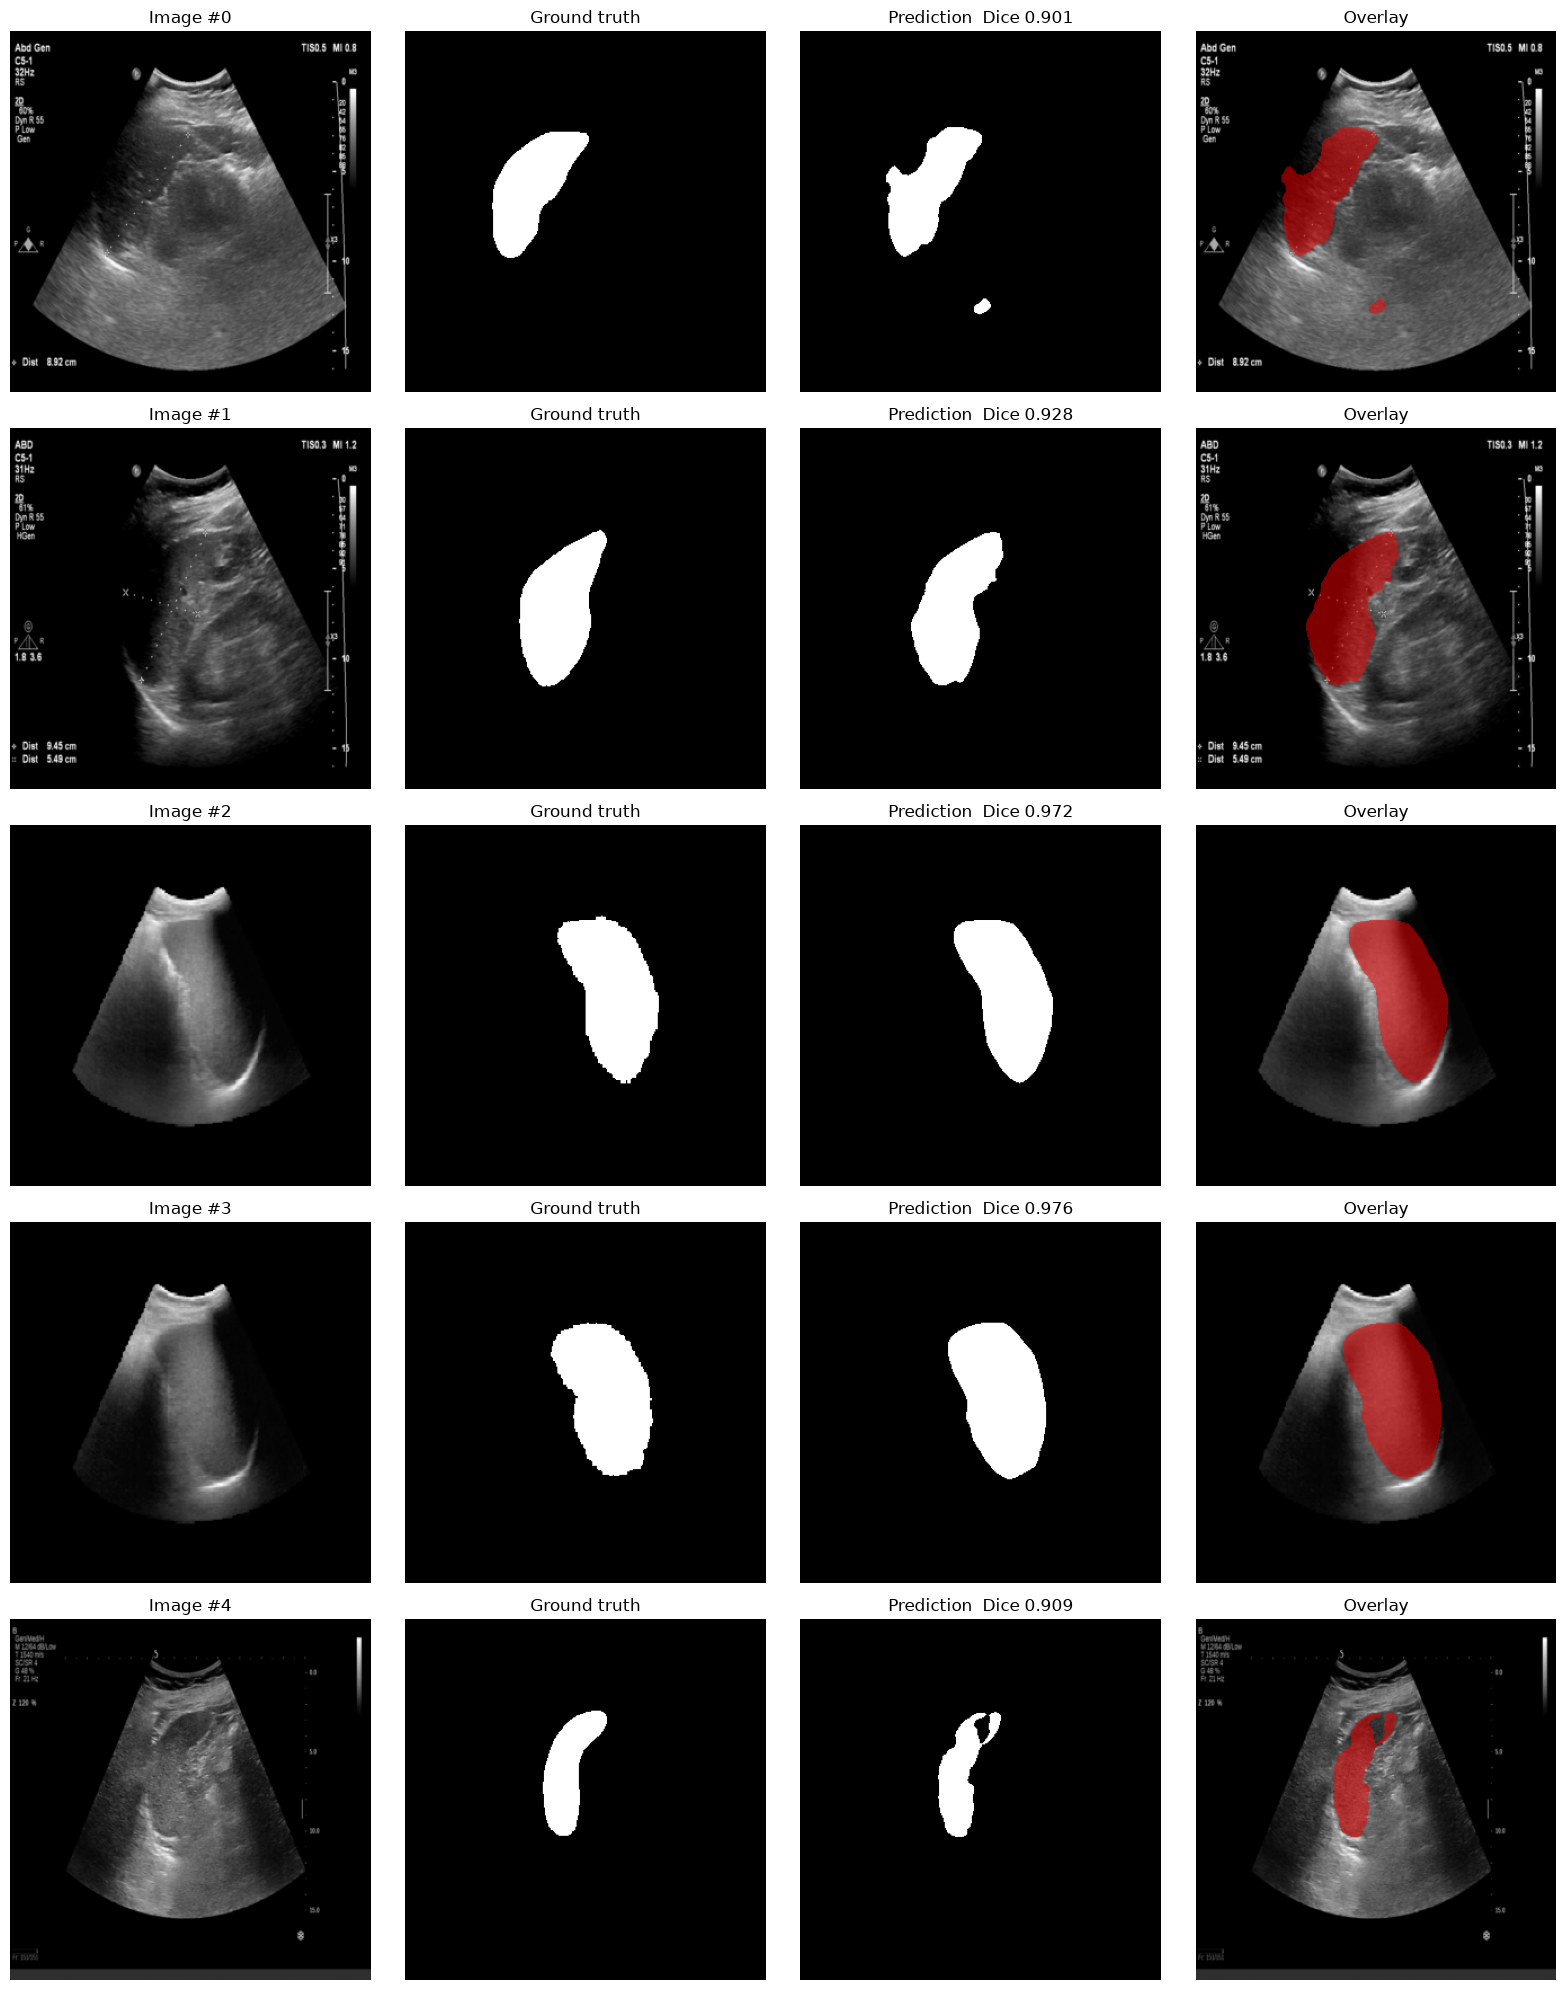

In [31]:
# visualize
model.visualize(X_test, y_test, n=5)

In [32]:
model = UNetSegmentor("unet3++")
model.load("/raid/mpsych/SPLEENUS/models/best_unet3pp.keras")

Automated hyper-parameter determination is applied with the following details:
----------
	Number of convolution filters after each full-scale skip connection: filter_num_skip = [64, 64, 64]
	Number of channels of full-scale aggregated feature maps: filter_num_aggregate = 256
Loaded from /raid/mpsych/SPLEENUS/models/best_unet3pp.keras


In [33]:
metrics = model.evaluate(X_test, y_test)

2026-09-09 22:02:00.151989: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Dice: 0.9174 | IoU: 0.8474


In [34]:
metrics = model.evaluate(X_robo, y_robo)

Dice: 0.4458 | IoU: 0.2868


In [6]:
from models.nnunet import NNUNetSegmentor
from data.spleenex import load_spleenex

In [10]:
model = NNUNetSegmentor("Dataset103_SpleenUS_DeepSPV", 103)

In [11]:
model.setup("/raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new")

nnUNet environment set up at: /raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new


In [12]:
model.prepare(X_train, y_train, X_test, y_test)

Saving 479 training cases...
Saving 120 test cases...
Saved to /raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new/nnUNet_raw/Dataset103_SpleenUS_DeepSPV
  Train: 479 | Test: 120
Running nnUNet preprocessing...
Fingerprint extraction...
Dataset103_SpleenUS_DeepSPV
Using <class 'nnunetv2.imageio.natural_image_reader_writer.NaturalImage2DIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.natural_image_reader_writer.NaturalImage2DIO'> as reader/writer


Extracting dataset fingerprint: 100%|██████████| 479/479 [00:03<00:00, 122.20it/s]


Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 22, 'patch_size': (np.int64(320), np.int64(320)), 'median_image_size_in_voxels': array([305., 307.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_sh

Preprocessing cases: 100%|██████████| 479/479 [00:04<00:00, 108.50it/s]


Preprocessing done.


In [13]:
model.fit()


=== Training fold 0 ===

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-09-04 08:54:39.176211: Using torch.compile...
2026-09-04 08:54:40.155940: do_dummy_2d_data_aug: False
2026-09-04 08:54:40.156992: Creating new 5-fold cross-validation split...
2026-09-04 08:54:40.180952: Desired fold for training: 0
2026-09-04 08:54:40.180990: This 

/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/_inductor/lowering.py:7007: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/_inductor/lowering.py:7007: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/_inductor/lowering.py:7007: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warn

using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 22, 'patch_size': [320, 320], 'median_image_size_in_voxels': [305.0, 307.0], 'spacing': [1.0, 1.0], 'normalization_schemes': ['ZScoreNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_shape', 'resampling_fn_probabilities_kwargs': {'is_seg': False, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'architecture': {'network_class_name': 'dynamic_network_architectures.architectures.unet.PlainConvUNet', 'arch_kwargs': {'n_stages': 7, 'feat

Traceback (most recent call last):
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/bin/nnUNetv2_train", line 6, in <module>
    sys.exit(run_training_entry())
             ^^^^^^^^^^^^^^^^^^^^
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 259, in run_training_entry
    run_training(args.dataset_name_or_id, args.configuration, args.fold, args.tr, args.p, args.pretrained_weights,
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 200, in run_training
    nnunet_trainer.run_training()
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py", line 1426, in run_training
    train_outputs.append(self.train_step(next(self.dataloader_train)))
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jiehyun.kim001/miniconda3/envs


=== Training fold 1 ===

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-09-04 10:55:11.615094: Using torch.compile...
2026-09-04 10:55:12.534371: do_dummy_2d_data_aug: False
2026-09-04 10:55:12.535433: Using splits from existing split file: /raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new/nnUNet_preprocessed/Dataset103_SpleenUS_DeepSPV/spli

...

Traceback (most recent call last):
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/bin/nnUNetv2_train", line 6, in <module>
    sys.exit(run_training_entry())
             ^^^^^^^^^^^^^^^^^^^^
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 259, in run_training_entry
    run_training(args.dataset_name_or_id, args.configuration, args.fold, args.tr, args.p, args.pretrained_weights,
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 200, in run_training
    nnunet_trainer.run_training()
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/training/nnUNetTrainer/nnUNetTrainer.py", line 1426, in run_training
    train_outputs.append(self.train_step(next(self.dataloader_train)))
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jiehyun.kim001/miniconda3/envs


=== Training fold 3 ===


Traceback (most recent call last):
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/bin/nnUNetv2_train", line 3, in <module>
    from nnunetv2.run.run_training import run_training_entry
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 6, in <module>
    import torch.cuda
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/__init__.py", line 409, in <module>
    from torch._C import *  # noqa: F403
    ^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 463, in _lock_unlock_module
KeyboardInterrupt



=== Training fold 4 ===


Traceback (most recent call last):
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/bin/nnUNetv2_train", line 3, in <module>
    from nnunetv2.run.run_training import run_training_entry
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/nnunetv2/run/run_training.py", line 6, in <module>
    import torch.cuda
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/__init__.py", line 2611, in <module>
    from torch import _meta_registrations
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/_meta_registrations.py", line 12, in <module>
    from torch._decomp import (
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/_decomp/__init__.py", line 276, in <module>
    import torch._decomp.decompositions
  File "/home/jiehyun.kim001/miniconda3/envs/impact-team-2/lib/python3.12/site-packages/torch/_decomp/decompositions.py"

In [7]:
model = NNUNetSegmentor("Dataset103_SpleenUS_DeepSPV", 103)

In [8]:
model.setup("/raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new")

nnUNet environment set up at: /raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new


In [9]:
model.load(folds=(0,1,2,3,4))

nnUNet loaded from: /raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new/nnUNet_results/Dataset103_SpleenUS_DeepSPV/nnUNetTrainer__nnUNetPlans__2d


In [17]:
metrics = model.evaluate(X_test, y_test)

100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 38.16it/s]


Dice: 0.9509 | IoU: 0.9064


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 49.08it/s]


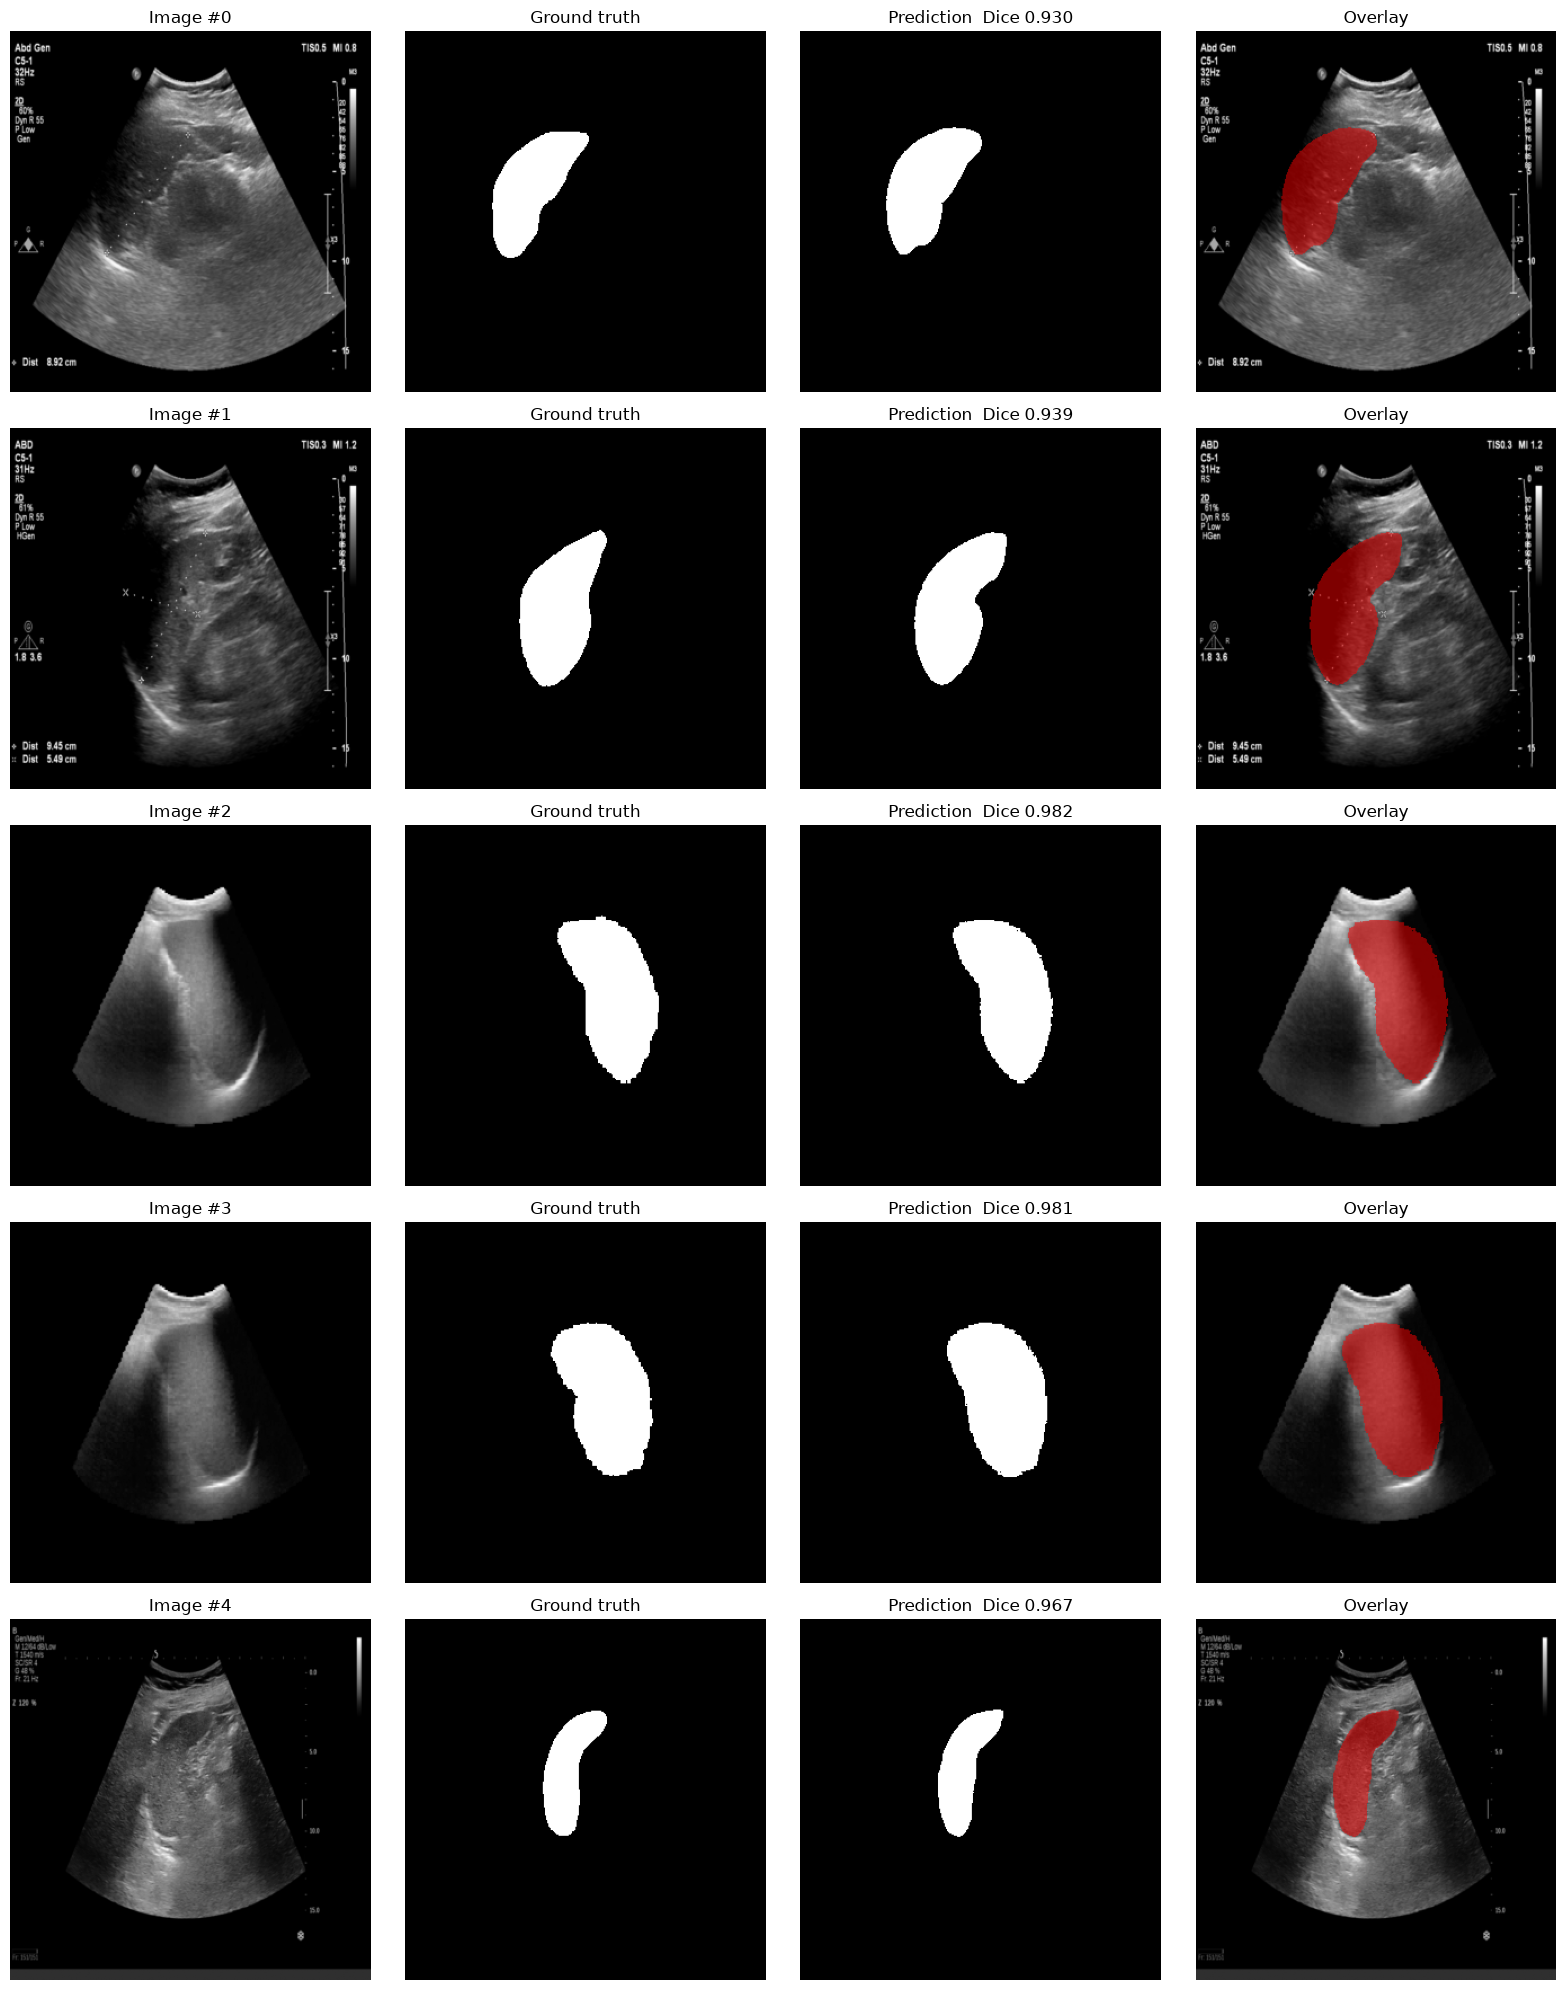

In [22]:
model.visualize(X_test, y_test, n=5)

In [11]:
metrics = model.evaluate(X_robo, y_robo)

100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 32.28it/s]


Dice: 0.8475 | IoU: 0.7353


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 44.34it/s]


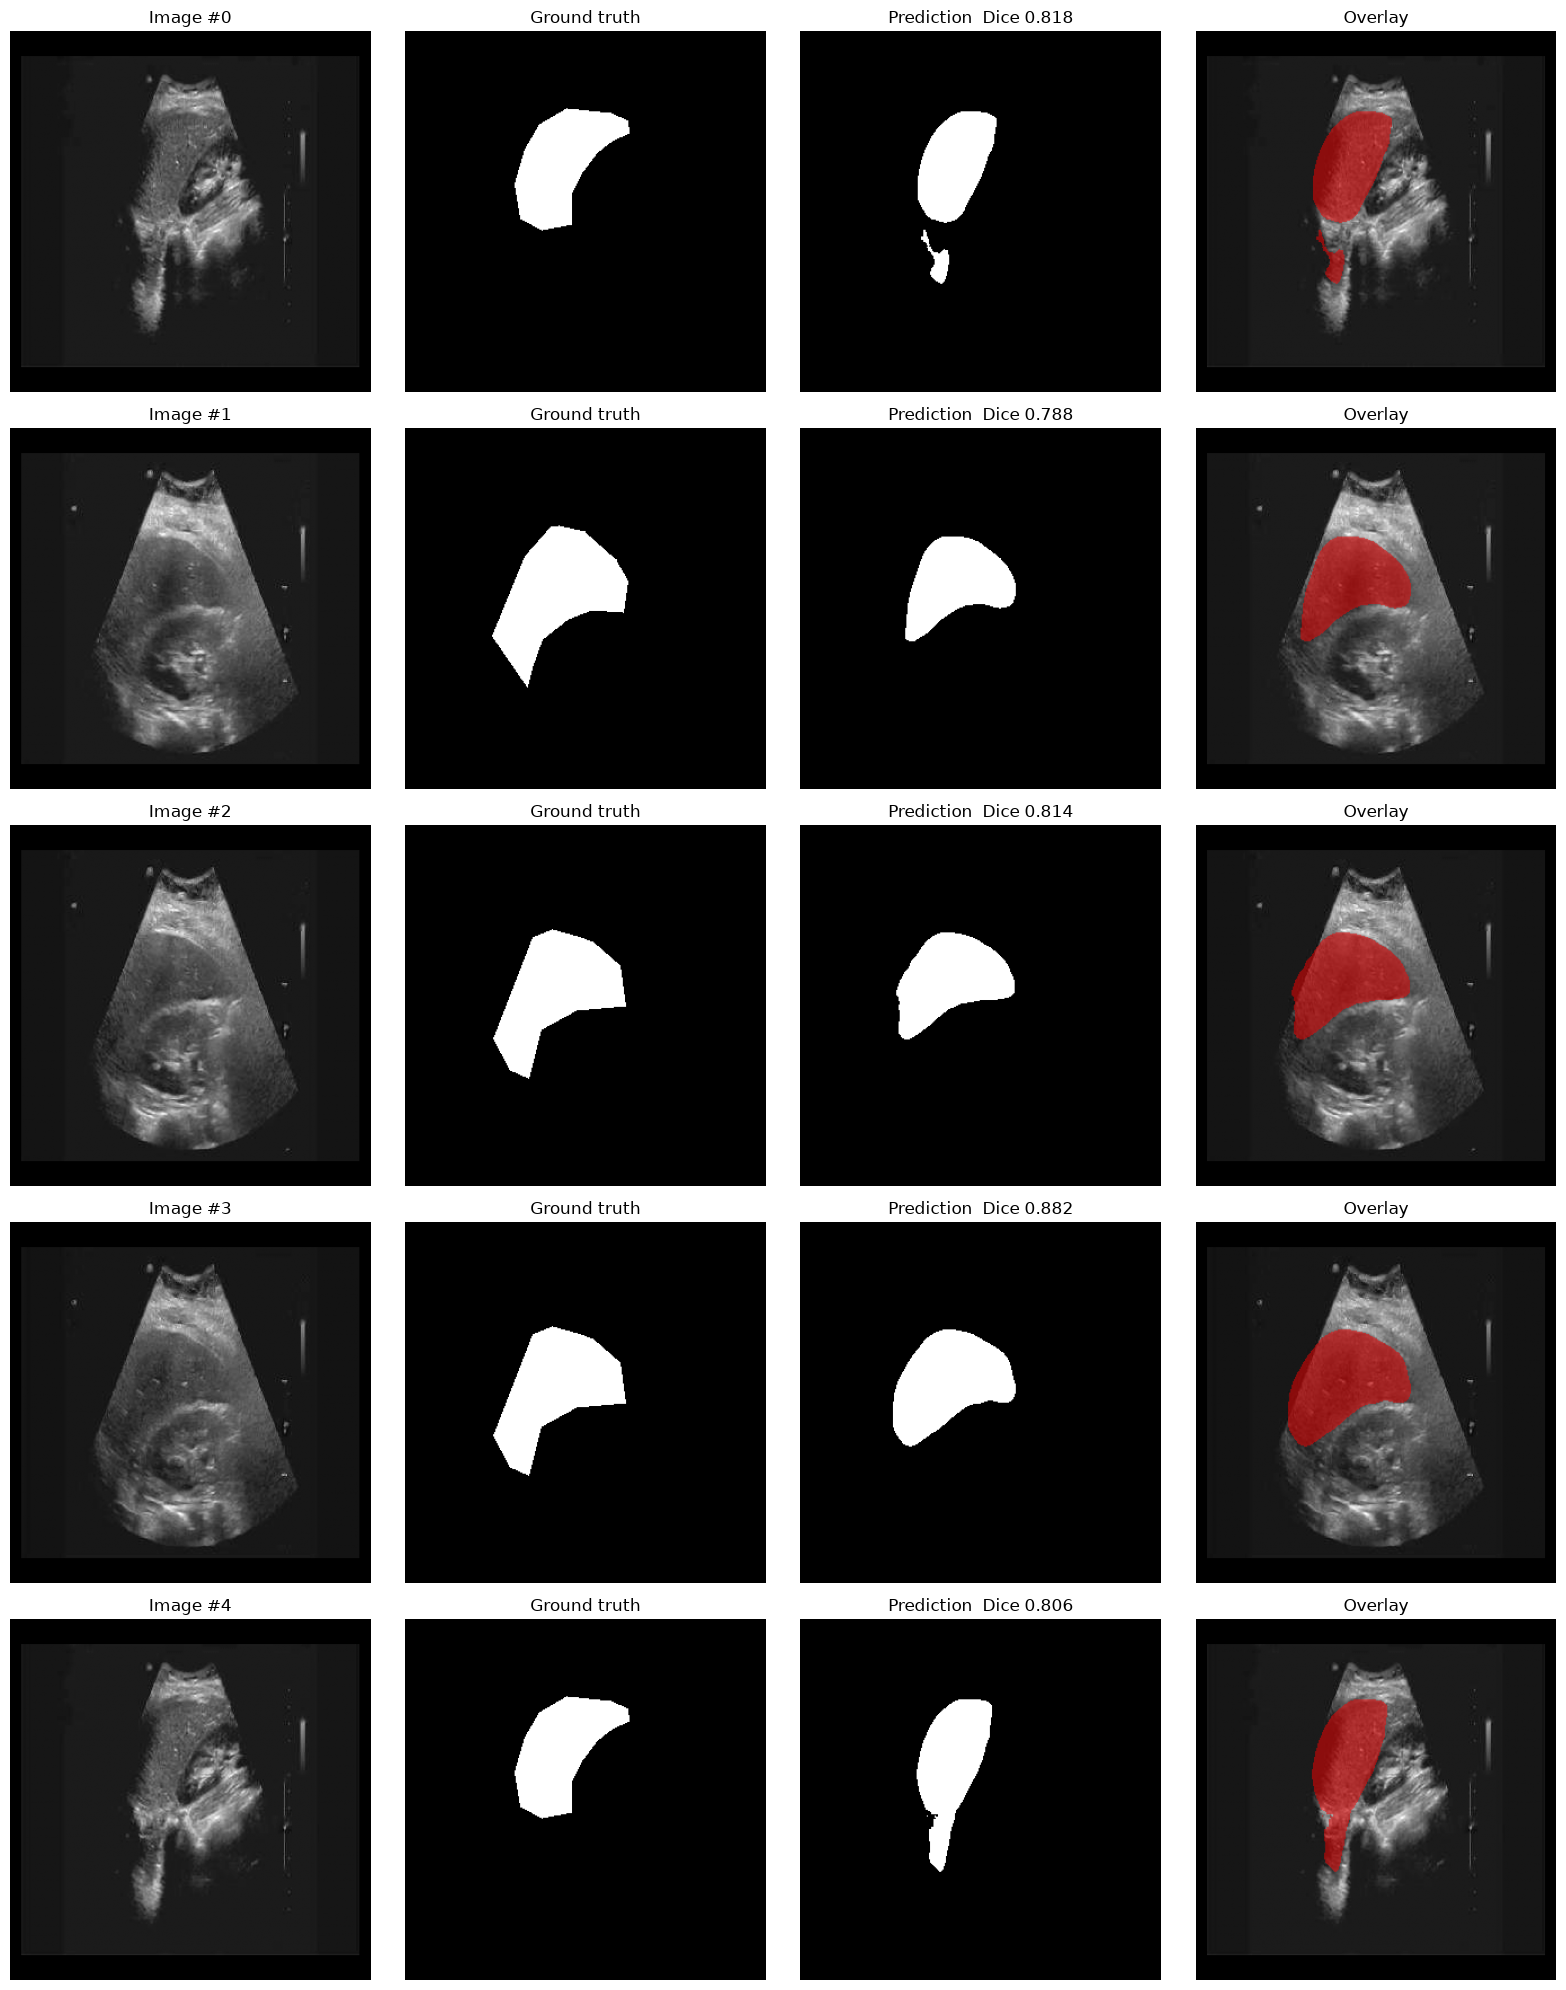

In [21]:
model.visualize(X_robo, y_robo, n=5)

In [ ]:
"""
SAM3 / MedSAM3 Experiments
===========================
Experiments:

SAM3:
  1. Baseline (text-only)
  2. Baseline + UNet++ bbox
  3. Baseline + nnUNet bbox
  4. Fine-tune (text-only)
  5. Fine-tune + UNet++ bbox
  6. Fine-tune + nnUNet bbox

MedSAM3:
  1. Baseline (text-only)
  2. Baseline + UNet++ bbox
  3. Baseline + nnUNet bbox 
  4. Fine-tune (text-only)
  5. Fine-tune + UNet++ bbox 
  6. Fine-tune + nnUNet bbox

All tested on Roboflow (unseen data).
"""

In [1]:
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'  # use GPU as needed

import sys
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

from dotenv import load_dotenv
load_dotenv('/home/jiehyun.kim001/SPLEENUS/team-SAMv3-impact/.env.local')

%matplotlib inline
import matplotlib.pyplot as plt

sys.path.insert(0, '../src')

from data.roboflow  import load_roboflow
from data.spleenex  import load_spleenex
from models.unet    import UNetSegmentor
from models.nnunet  import NNUNetSegmentor
from models.sam_models import SAM3Segmentor, MedSAM3Segmentor
from config import RUNS_ROOT

2026-09-09 00:03:23.330496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788926603.347502  570569 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788926603.352753  570569 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788926603.365228  570569 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788926603.365246  570569 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788926603.365248  570569 computation_placer.cc:177] computation placer alr

In [2]:
# 1. Load data

print("=== Loading data ===")
X_train, y_train, X_test, y_test = load_spleenex()
X_robo,  y_robo,  _,      _      = load_roboflow(split=False)

print(f"Train: {X_train.shape} | Test: {X_test.shape} | Roboflow: {X_robo.shape}")

=== Loading data ===
Spleenex: loaded 450 samples (0 skipped)
Spleenex: spleen coverage 5.64%
Split: 382 train / 68 test (total 450)
Split log saved: /raid/mpsych/SPLEENUS/runs/splits/spleenex_seed42.json
Roboflow: loaded 208 samples
Roboflow: spleen coverage 7.14%
Train: (382, 320, 320, 1) | Test: (68, 320, 320, 1) | Roboflow: (208, 320, 320, 1)


In [3]:
# 2. Load bbox models (UNet++ and nnUNet)

print("\n=== Loading bbox models ===")

unet_model = UNetSegmentor("unet++")
unet_model.load("/raid/mpsych/SPLEENUS/models/best_unetpp.keras")

nn_model = NNUNetSegmentor("Dataset103_SpleenUS_DeepSPV", 103)
nn_model.setup("/raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new")
nn_model.load(folds=(0, 1, 2, 3, 4))


=== Loading bbox models ===
Loaded from /raid/mpsych/SPLEENUS/models/best_unetpp.keras
nnUNet environment set up at: /raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new
nnUNet loaded from: /raid/mpsych/SPLEENUS/nnunet_spl_deepspv_new/nnUNet_results/Dataset103_SpleenUS_DeepSPV/nnUNetTrainer__nnUNetPlans__2d


In [ ]:
# SAM3 experiments

In [4]:
# --- SAM3 1. Baseline (text-only) ---
print("\n=== SAM3 1. Baseline (text-only) ===")
sam = SAM3Segmentor()
sam.load()
metrics_sam_base = sam.evaluate(X_robo, y_robo)
print(metrics_sam_base)


=== SAM3 1. Baseline (text-only) ===


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

[sam3] ready on cuda
Dice: 0.0000 | IoU: 0.0000
{'dice': 6.575058423066715e-13, 'iou': 6.575058423066715e-13}


In [5]:
# --- SAM3 2. Baseline + UNet bbox ---
print("\n=== SAM3 2. Baseline + UNet3++ bbox ===")
metrics_sam_base_unet = sam.evaluate_with_bbox(X_robo, y_robo, bbox_model=unet_model)
print(metrics_sam_base_unet)


=== SAM3 2. Baseline + UNet3++ bbox ===


2026-09-08 22:19:40.362327: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
I0000 00:00:1788920380.593723  490774 cuda_dnn.cc:529] Loaded cuDNN version 90501


Dice: 0.7197 | IoU: 0.5622
{'dice': 0.719717264175415, 'iou': 0.5621549487113953}


In [6]:
# --- SAM3 3. Baseline + nnUNet bbox ---
print("\n=== SAM3 3. Baseline + nnUNet bbox ===")
metrics_sam_base_nn = sam.evaluate_with_bbox(X_robo, y_robo, bbox_model=nn_model)
print(metrics_sam_base_nn)


=== SAM3 3. Baseline + nnUNet bbox ===


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 49.92it/s]


Dice: 0.8137 | IoU: 0.6860
{'dice': 0.8137283325195312, 'iou': 0.6859544515609741}


In [4]:
# --- SAM3 4. Fine-tune ---
print("\n=== SAM3 4. Fine-tuning ===")
sam_ft = SAM3Segmentor()
sam_ft.fit(
    X_train, y_train,
    epochs=10,
    output_dir=os.path.join(RUNS_ROOT, "sam3_finetune_new2"),
    box_source="gt",
)


=== SAM3 4. Fine-tuning ===


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

[sam3-train] device=cuda trainable_params=2,298,881 prompt=text+box
[sam3-train][epoch 1/10] train_dice=0.8888, train_iou=0.7999, train_loss=0.0407 | val_dice=0.9112, val_iou=0.8369, val_loss=0.0275
[sam3-train][epoch 2/10] train_dice=0.9218, train_iou=0.8550, train_loss=0.0222 | val_dice=0.9161, val_iou=0.8452, val_loss=0.0297
[sam3-train][epoch 3/10] train_dice=0.9280, train_iou=0.8656, train_loss=0.0199 | val_dice=0.9041, val_iou=0.8249, val_loss=0.0293
[sam3-train][epoch 4/10] train_dice=0.9310, train_iou=0.8709, train_loss=0.0189 | val_dice=0.9184, val_iou=0.8491, val_loss=0.0240
[sam3-train][epoch 5/10] train_dice=0.9320, train_iou=0.8726, train_loss=0.0185 | val_dice=0.9222, val_iou=0.8556, val_loss=0.0231
[sam3-train][epoch 6/10] train_dice=0.9369, train_iou=0.8813, train_loss=0.0170 | val_dice=0.9295, val_iou=0.8684, val_loss=0.0206
[sam3-train][epoch 7/10] train_dice=0.9379, train_iou=0.8831, train_loss=0.0164 | val_dice=0.9063, val_iou=0.8287, val_loss=0.0287
[sam3-train][ep

In [5]:
# --- SAM3 4. Fine-tune (text-only) ---
print("\n=== SAM3 4. Fine-tune (text-only) ===")
sam_ft.load(weights_path=os.path.join(RUNS_ROOT, "sam3_finetune_new2/sam3_finetuned_weights.safetensors"))
metrics_sam_ft = sam_ft.evaluate(X_robo, y_robo)
print(metrics_sam_ft)


=== SAM3 4. Fine-tune (text-only) ===


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

[sam3] loaded fine-tuned weights from /raid/mpsych/SPLEENUS/runs/sam3_finetune_new2/sam3_finetuned_weights.safetensors (missing=1436, unexpected=0)
[sam3] ready on cuda
Dice: 0.0000 | IoU: 0.0000
{'dice': 6.575058423066715e-13, 'iou': 6.575058423066715e-13}


In [6]:
# --- SAM3 5. Fine-tune + UNet bbox ---
print("\n=== SAM3 5. Fine-tune + UNet bbox ===")
metrics_sam_ft_unet = sam_ft.evaluate_with_bbox(X_robo, y_robo, bbox_model=unet_model)
print(metrics_sam_ft_unet)


=== SAM3 5. Fine-tune + UNet bbox ===


2026-09-08 22:59:10.396847: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
I0000 00:00:1788922750.657455  501608 cuda_dnn.cc:529] Loaded cuDNN version 90501


Dice: 0.7341 | IoU: 0.5798
{'dice': 0.7340538501739502, 'iou': 0.5798460245132446}


In [7]:
# --- SAM3 6. Fine-tune + nnUNet bbox ---
print("\n=== SAM3 6. Fine-tune + nnUNet bbox ===")
metrics_sam_ft_nn = sam_ft.evaluate_with_bbox(X_robo, y_robo, bbox_model=nn_model)
print(metrics_sam_ft_nn)


=== SAM3 6. Fine-tune + nnUNet bbox ===


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 43.82it/s]


Dice: 0.8242 | IoU: 0.7010
{'dice': 0.8242409229278564, 'iou': 0.7010287046432495}


In [ ]:
# MedSAM3 experiments

In [4]:
# --- MedSAM3 1. Baseline (text-only) ---
print("\n=== MedSAM3 1. Baseline (text-only) ===")
medsam = MedSAM3Segmentor()
medsam.load()
metrics_medsam_base = medsam.evaluate(X_robo, y_robo)
print(metrics_medsam_base)


=== MedSAM3 1. Baseline (text-only) ===


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

[lora] replaced 61 nn.MultiheadAttention -> MultiheadAttentionLoRA
[lora] applied LoRA to 458 Linear layers
[lora] loaded LoRA weights from /home/jiehyun.kim001/.cache/huggingface/hub/models--lal-Joey--MedSAM3_v1/snapshots/f579e37e4db9f2c7e85a133b7970d59907e36fec/best_lora_weights.pt (916 tensors)
[medsam3] ready on cuda (weights: /home/jiehyun.kim001/.cache/huggingface/hub/models--lal-Joey--MedSAM3_v1/snapshots/f579e37e4db9f2c7e85a133b7970d59907e36fec/best_lora_weights.pt)
Dice: 0.4066 | IoU: 0.2552
{'dice': 0.40661588311195374, 'iou': 0.2551901042461395}


In [5]:
# --- MedSAM3 2. Baseline + UNet++ bbox ---
print("\n=== MedSAM3 2. Baseline + UNet bbox ===")
metrics_medsam_base_unet = medsam.evaluate_with_bbox(X_robo, y_robo, bbox_model=unet_model)
print(metrics_medsam_base_unet)


=== MedSAM3 2. Baseline + UNet bbox ===


2026-09-08 21:14:57.020541: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
I0000 00:00:1788916497.252073  441708 cuda_dnn.cc:529] Loaded cuDNN version 90501


Dice: 0.7106 | IoU: 0.5511
{'dice': 0.7105919718742371, 'iou': 0.5510993599891663}


In [6]:
# --- MedSAM3 3. Baseline + nnUNet bbox  ---
print("\n=== MedSAM3 3. Baseline + nnUNet bbox  ===")
metrics_medsam_base_nn = medsam.evaluate_with_bbox(X_robo, y_robo, bbox_model=nn_model)
print(metrics_medsam_base_nn)


=== MedSAM3 3. Baseline + nnUNet bbox  ===




  0%|                                                                                        | 0/1 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.17it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 37.46it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 46.61it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 42.08it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 31.58it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 47.85it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 47.29it/s]


100%|██████████████████████████████████████████████████

Dice: 0.7312 | IoU: 0.5763
{'dice': 0.7312153577804565, 'iou': 0.5763115882873535}


In [4]:
# --- MedSAM3 4. Fine-tune on text only---
print("\n=== MedSAM3 4. Fine-tuning ===")
medsam_ft = MedSAM3Segmentor()
# medsam_ft.fit(
#     X_train, y_train,
#     epochs=10,
#     output_dir=os.path.join(RUNS_ROOT, "medsam3_finetune_new2"),
# )


=== MedSAM3 4. Fine-tuning ===
[medsam3-train] building model on cuda...
[lora] replaced 61 nn.MultiheadAttention -> MultiheadAttentionLoRA
[lora] applied LoRA to 458 Linear layers


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

[lora] loaded LoRA weights from /home/jiehyun.kim001/.cache/huggingface/hub/models--lal-Joey--MedSAM3_v1/snapshots/f579e37e4db9f2c7e85a133b7970d59907e36fec/best_lora_weights.pt (916 tensors)
[medsam3-train] warm-started from /home/jiehyun.kim001/.cache/huggingface/hub/models--lal-Joey--MedSAM3_v1/snapshots/f579e37e4db9f2c7e85a133b7970d59907e36fec/best_lora_weights.pt
[medsam3-train] trainable: 18,497,664 (2.15%)
[medsam3-train] train=306 val=76


[medsam3-train] epoch 1: 100%|█████████████████████████████████████████████████████| 77/77 [03:40<00:00,  2.87s/it]


...

[medsam3-train][epoch 8/10] train_loss=16.7683 val_loss=2.3929
[lora] saved 458 LoRA layers -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_new2/last_lora_weights.pt


[medsam3-train] epoch 9: 100%|█████████████████████████████████████████████████████| 77/77 [03:35<00:00,  2.80s/it]


[medsam3-train][epoch 9/10] train_loss=15.9066 val_loss=2.4383
[lora] saved 458 LoRA layers -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_new2/last_lora_weights.pt


[medsam3-train] epoch 10: 100%|████████████████████████████████████████████████████| 77/77 [03:36<00:00,  2.81s/it]


[medsam3-train][epoch 10/10] train_loss=15.8150 val_loss=2.5287
[lora] saved 458 LoRA layers -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_new2/last_lora_weights.pt
[MedSAM3] fine-tuned weights -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_new2/best_lora_weights.pt


In [5]:
# --- MedSAM3 4. Fine-tune (text-only) ---
print("\n=== MedSAM3 4. Fine-tune (text-only) ===")
medsam_ft.load(weights_path=os.path.join(RUNS_ROOT, "medsam3_finetune_new2/best_lora_weights.pt"))
metrics_medsam_ft = medsam_ft.evaluate(X_robo, y_robo)
print(metrics_medsam_ft)


=== MedSAM3 4. Fine-tune (text-only) ===
[lora] replaced 61 nn.MultiheadAttention -> MultiheadAttentionLoRA
[lora] applied LoRA to 458 Linear layers
[lora] loaded LoRA weights from /raid/mpsych/SPLEENUS/runs/medsam3_finetune_new2/best_lora_weights.pt (916 tensors)
[medsam3] ready on cuda (weights: /raid/mpsych/SPLEENUS/runs/medsam3_finetune_new2/best_lora_weights.pt)
Dice: 0.8515 | IoU: 0.7414
{'dice': 0.8514814376831055, 'iou': 0.7413737177848816}


In [6]:
# --- MedSAM3 5. Fine-tune + UNet++ bbox ---
print("\n=== MedSAM3 5. Fine-tune + UNet++ bbox===")
metrics_medsam_ft_unet = medsam_ft.evaluate_with_bbox(X_robo, y_robo, bbox_model=unet_model)
print(metrics_medsam_ft_unet)


=== MedSAM3 5. Fine-tune + UNet++ bbox===


2026-09-08 22:09:03.553859: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
I0000 00:00:1788919743.792446  453371 cuda_dnn.cc:529] Loaded cuDNN version 90501


Dice: 0.8418 | IoU: 0.7269
{'dice': 0.8418223261833191, 'iou': 0.7268508076667786}


In [7]:
# --- MedSAM3 6. Fine-tune + nnUNet bbox  ---
print("\n=== MedSAM3 6. Fine-tune + nnUNet bbox  ===")
metrics_medsam_ft_nn = medsam_ft.evaluate_with_bbox(X_robo, y_robo, bbox_model=nn_model)
print(metrics_medsam_ft_nn)


=== MedSAM3 6. Fine-tune + nnUNet bbox  ===


100%|████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 36.15it/s]


Dice: 0.8487 | IoU: 0.7372
{'dice': 0.8487064838409424, 'iou': 0.7371764779090881}


In [ ]:
# MedSAM Finetune on text+bbox

In [4]:
medsam_ft2 = MedSAM3Segmentor()

In [5]:
medsam_ft2.fit(X_train, y_train, epochs=10,
               output_dir=os.path.join(RUNS_ROOT, "medsam3_finetune_boxprompt"),
               box_source="gt")

[medsam3-train] building model on cuda...
[lora] replaced 61 nn.MultiheadAttention -> MultiheadAttentionLoRA
[lora] applied LoRA to 458 Linear layers


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

[lora] loaded LoRA weights from /home/jiehyun.kim001/.cache/huggingface/hub/models--lal-Joey--MedSAM3_v1/snapshots/f579e37e4db9f2c7e85a133b7970d59907e36fec/best_lora_weights.pt (916 tensors)
[medsam3-train] warm-started from /home/jiehyun.kim001/.cache/huggingface/hub/models--lal-Joey--MedSAM3_v1/snapshots/f579e37e4db9f2c7e85a133b7970d59907e36fec/best_lora_weights.pt
[medsam3-train] trainable: 18,497,664 (2.15%)
[medsam3-train] train=306 val=76


[medsam3-train] epoch 1: 100%|█████████████████████████████████████████████████████| 77/77 [03:40<00:00,  2.87s/it]


...

[medsam3-train][epoch 8/10] train_loss=16.1616 val_loss=2.4661
[lora] saved 458 LoRA layers -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_boxprompt/last_lora_weights.pt


[medsam3-train] epoch 9: 100%|█████████████████████████████████████████████████████| 77/77 [03:35<00:00,  2.80s/it]


[medsam3-train][epoch 9/10] train_loss=15.6531 val_loss=2.5877
[lora] saved 458 LoRA layers -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_boxprompt/last_lora_weights.pt


[medsam3-train] epoch 10: 100%|████████████████████████████████████████████████████| 77/77 [03:35<00:00,  2.80s/it]


[medsam3-train][epoch 10/10] train_loss=14.9166 val_loss=2.6452
[lora] saved 458 LoRA layers -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_boxprompt/last_lora_weights.pt
[MedSAM3] fine-tuned weights -> /raid/mpsych/SPLEENUS/runs/medsam3_finetune_boxprompt/best_lora_weights.pt


In [6]:
medsam_ft2.load(weights_path=os.path.join(RUNS_ROOT, "medsam3_finetune_boxprompt/best_lora_weights.pt"))

[lora] replaced 61 nn.MultiheadAttention -> MultiheadAttentionLoRA
[lora] applied LoRA to 458 Linear layers
[lora] loaded LoRA weights from /raid/mpsych/SPLEENUS/runs/medsam3_finetune_boxprompt/best_lora_weights.pt (916 tensors)
[medsam3] ready on cuda (weights: /raid/mpsych/SPLEENUS/runs/medsam3_finetune_boxprompt/best_lora_weights.pt)


In [8]:
print(medsam_ft2.evaluate(X_robo, y_robo))                                  # text-only
print(medsam_ft2.evaluate_with_bbox(X_robo, y_robo, bbox_model=unet_model)) # text+bbox
print(medsam_ft2.evaluate_with_bbox(X_robo, y_robo, bbox_model=nn_model))   # text+bbox

Dice: 0.8477 | IoU: 0.7356
{'dice': 0.8476629257202148, 'iou': 0.7356032133102417}


2026-09-09 00:47:00.472014: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
I0000 00:00:1788929220.689926  570992 cuda_dnn.cc:529] Loaded cuDNN version 90501


Dice: 0.8407 | IoU: 0.7252
{'dice': 0.8407033681869507, 'iou': 0.7251840233802795}


  0%|                                                                                        | 0/1 [00:00<?, ?it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Dice: 0.8504 | IoU: 0.7397
{'dice': 0.8504055142402649, 'iou': 0.7397439479827881}
